# Non-Uniform Alpha Values: Figures 13 And 14

This notebook was added for Appendix B.6. The corresponding W&B tag is `non-uniform-span-weights`, where positions inside each span use weights `[0.7, 0.3]`.


In [1]:
from analysis.utils import fetch_run_data, plot_combined_heads, plot_kl_divergence_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
RUN_ID = "mgj8u2o3"
run_data = fetch_run_data(RUN_ID, metrics=["val_loss"])
cfg = run_data["config"]
pd.DataFrame(
    [{
        "run_id": RUN_ID,
        "name": run_data["name"],
        "tag": "non-uniform-span-weights",
        "span_position_weights": cfg["teacher"].get("span_position_weights"),
        "span_lengths": cfg["teacher"]["span_lengths"],
    }]
)


,run_id,name,tag,span_position_weights,span_lengths
0,mgj8u2o3,resilient-microwave-1929,non-uniform-span-weights,"[0.7, 0.3]","[2, 2, 2]"


## Figure 13: KL Divergence

The KL curves show that non-uniform within-span weights do not remove the incremental acquisition of feature groups.


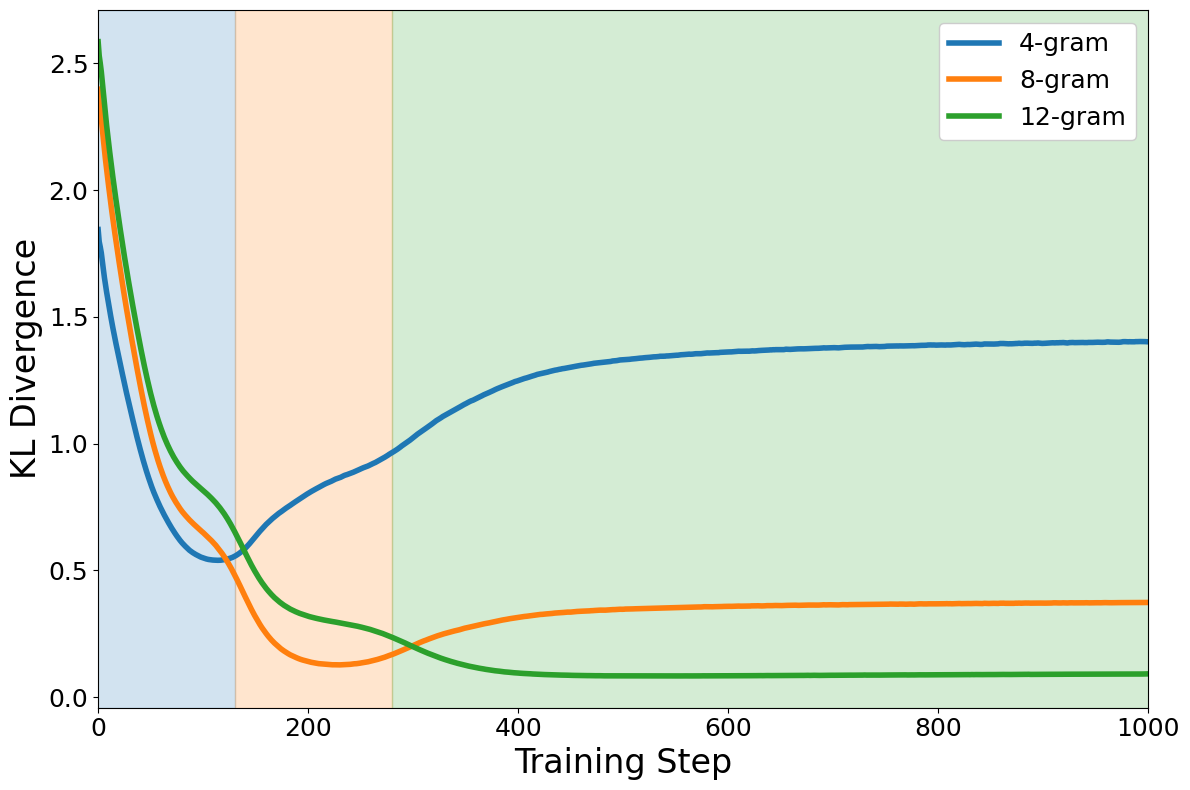

In [3]:
plot_kl_divergence_simple(
    run_id=RUN_ID,
    learnable=True,
    divergence_steps=[2130, 2280],
    max_steps=3000,
    shift_steps=2000,
    save_name=output_path("kl-non-uniform-alpha"),
)


## Figure 14: Attention Patterns

The checkered structure reflects the larger alpha weight on the first position inside each span.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


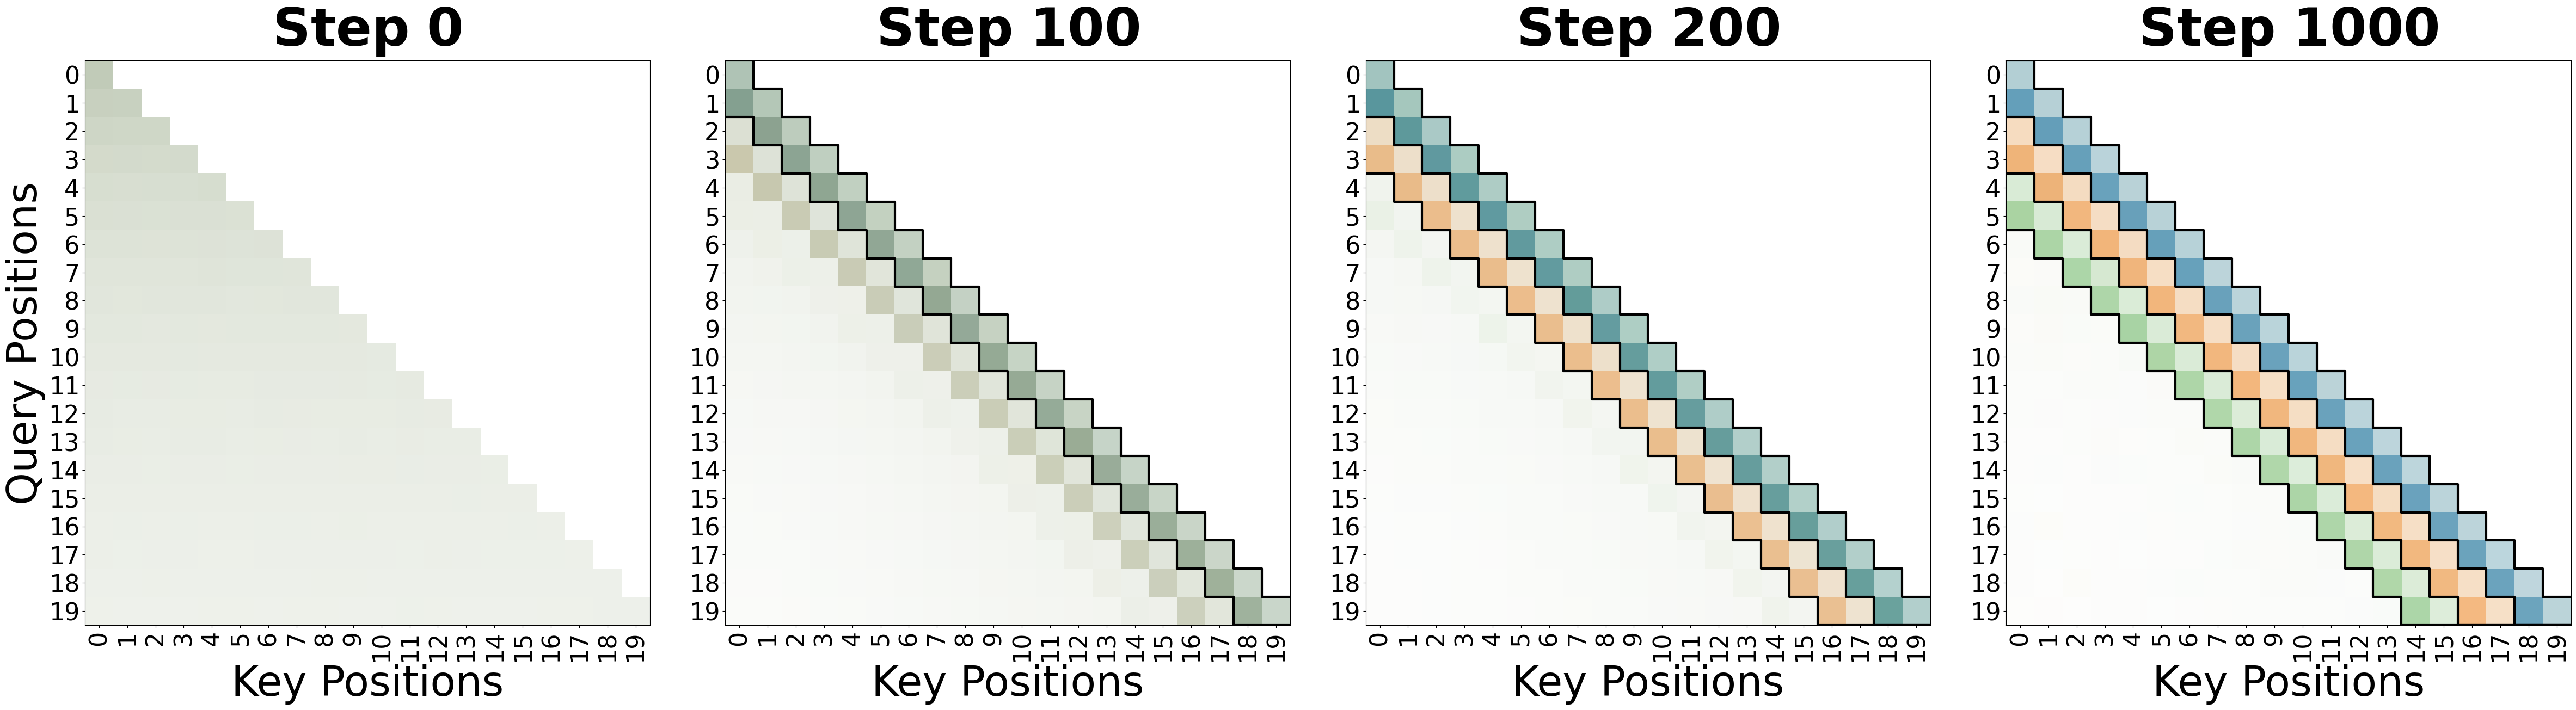

In [4]:
plot_combined_heads(
    RUN_ID,
    steps=[0, 100, 200, 1000],
    frequency=50,
    split="val",
    head_colors=report_head_color_map([2, 1, 0]),
    staircases={1: [0, -2], 2: [0, -2, -4], 3: [0, -2, -4, -6]},
    save_name=output_path("attention-non-uniform-alpha"),
)
